<h1 style="color:lightblue; text-align:center;">Datasci 151 Final Project</h1>
<h3 style="color:lightblue; text-align:center;">Neko, Tae, William</h3>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

<h2 style="color:lightblue; text-align:center;">Preliminary Data Description</h2>
First, given that the project required data cleaning, numerical calculation, and plotting, we imported three libraries - pandas, numpy, and matplotlib.pyplot.

We used four data throughout the analysis - results.csv, constructors.csv, drivers.csv, and pit_stops.csv.

results.csv: The data has 25660 rows, where each observational unit is a specific driver's performance in a specific race. The variables we are interested in are points, millisecond, and rank. Points here means the numerical points awarded to the driver based on their finishing position. We would use this as our response variable in some analysis. Millisecond in this dataset means the race duration a driver takes. The units was changed to minutes in subsequent data analysis. This is another measure for the drivers' performance. Points demonstrates a driver's comparative performance, while the race duration shows a driver's absolute performance. We provide both for subsequent data analysis. Rank means the order of the driver's fastest lap compared to other drivers in the same race. Given the bonus point system in F1, we want to see if rank have any effect on points.

constructors.csv: The data has 211 rows, where each observational unit is a specific constructor. The variable we are interested in is the constructor's nationality. There's always debate on which country produces the best cars. Thus, we want to see if constructor's nationality have any effect on points.

drivers.csv: The data has 854 rows, where each observational unit is a specific driver/racer. The variable we are interested in are the driver's nationality and date of birth. We want to see which countries have the most drivers or better driver performance. The date of birth could be a variable or controlled factor. It might be the case that older drivers were more experienced. However young drivers may have more enhanced race cars and better equipments.

pit_stops.csv: The data has 9299 rows, where each observational unit is a specific driver in a specific races' specific stop. The variable we are interested in is duration, which is the pit stop time. Note some calculated the pit stop time to be only the time for changing tire, which should be about 2 to 3 seconds on average. This dataset used another definition of pit stop time that also included pit stop duration and pit lane entry/exit time. We want to see if pit stop time have any effect on drivers' points.

races.csv: The data has 1079 rows, where each observational unit is a specific race. The variable we are interested in is year, the time the race took place in. Again, this variable is needed for controlling any biases given that drivers' performances  in different year segments weren't apple to apple comparisons. It should be strongly related with the race duration given technological improvements.



In [ ]:
df_results = pd.read_csv("1-Formula_One/results.csv")
df_constructors = pd.read_csv("1-Formula_One/constructors.csv")
df_drivers = pd.read_csv("1-Formula_One/drivers.csv")
df_pitstops = pd.read_csv("1-Formula_One/pit_stops.csv")
df_races = pd.read_csv("1-Formula_One/races.csv")
display(len(df_results))
display(len(df_constructors))
display(len(df_drivers))
display(len(df_pitstops))
display(len(df_races))
#mean_pit_stop_time=(df_pitstops_exclude_outlier["milliseconds"].mean())/1000




FileNotFoundError: [Errno 2] No such file or directory: '1-Formula_One/results.csv'

<h2 style="color:lightblue; text-align:center;">Data Cleaning</h2>

We first converted several quantitative variables to numeric format by replacing all non-numeric values with np.nan. Then, we renamed some variables to avoid confusion; for example, we clarified the difference between "constructor_nationality" and "driver_nationality."

Major adjustments were made to the pitstops.csv dataset. We noticed that several pit stop times were extremely large, which skewed the average value significantly. These instances likely represent rare situations where the racing car was severely damaged and did not finish the race. Since these are exceptional cases, we decided to remove them so that they would not disproportionately affect the mean values.

We also refined the time variables. For time-related fields, we converted them to datetime format to enable correct plotting of graphs and further time-series analysis. For the year variable in race.csv, we recoded it into categorical variables to better suit our data analysis objectives.

In [ ]:

df_results = df_results[["resultId","raceId","driverId","constructorId","points","rank","milliseconds"]]
df_results["race_time_ms"] = pd.to_numeric(df_results["milliseconds"], errors = "coerce")
df_results['race_duration_minutes'] = df_results['race_time_ms'] / (1000*60)
df_results["rank"] = pd.to_numeric(df_results["rank"], errors='coerce')
df_results["points"] = pd.to_numeric(df_results["points"], errors='coerce')
df_constructors.rename(columns={'nationality':'constructor_nationality'}, inplace=True)
df_drivers.rename(columns={'nationality':'driver_nationality'}, inplace=True)
df_drivers['date_of_birth'] = pd.to_datetime(df_drivers['dob'], format='%Y-%m-%d')
df_pitstops_exclude_outlier=df_pitstops.query("milliseconds<50000")
df_pitstops_groupby = (df_pitstops_exclude_outlier.groupby(["driverId"])
                        .agg(mean_pit_stop_time = ('milliseconds','mean')).reset_index())
df_pitstops_groupby["mean_pit_stop_time"] = np.round(df_pitstops_groupby["mean_pit_stop_time"]/100,2)

lat_bins = [1950, 1960, 1970,1980,1990,2000,2010,2023]
lat_labels = ["1950-1960", "1960-1970","1970-1980","1980-1990","1990-2000","2000-2010","2010-2022"]
df_races["year_segment"] = pd.cut(df_races["year"],
                                bins = lat_bins,
                              right = False,
                               labels = lat_labels)


NameError: name 'df_results' is not defined

<h2 style="color:lightblue; text-align:center;">Data Cleaning</h2>

Lastly, we merged all five datasets based on the *Id shared by both data through each round of merge.

Result.csv is our main dataset. We appended constructors.csv, drivers.csv, race.csv, and pitstops.csv in order.

In [ ]:
merge_1 = pd.merge(left = df_results,
                       right = df_constructors[["constructorId", "constructor_nationality"]],
                       on = "constructorId",
                       how = "left")
merge_2 = pd.merge(left = merge_1,
                       right = df_drivers[["driverId", "driver_nationality","date_of_birth"]],
                       on = "driverId",
                       how = "left")

merge_3 = pd.merge(left = merge_2,
                   right = df_races[["raceId","year_segment"]],
                   on = "raceId",
                   how = "left")
final_merge = pd.merge(left = merge_3,
                       right = df_pitstops_groupby[["driverId", "mean_pit_stop_time"]],
                       on = "driverId",
                       how = "left")


<h2 style="color:lightblue; text-align:center;"> Main Dataset after cleaning</h2>
Lastly, we grouped the data by driver and constructor, and calculated relevant statistics for each combination. We removed any rows where the standard deviation of race duration was zero (indicating only one observational unit) or where there were missing values, in order to avoid bias in our results.

In addition to using the categorical variables described in the data documentation, we created several descriptive quantitative variables: the mean and standard deviation for points, the mean and standard deviation for race duration (in minutes), and the mean pit stop time (in seconds). These variables serve as references and will be utilized in further stages of our data analysis.

In [ ]:
result_groupby = (final_merge.groupby(["driverId","constructorId"])
                        .agg(mean_rank = ('rank','mean'),
                             sd_rank = ('rank','std'),
                             mean_race_duration_minutes = ('race_duration_minutes','mean'),
                             sd_race_duration_minutes = ('race_duration_minutes','std'),
                             mean_points = ('points','mean'),
                             sd_points = ('points','std'),
                             driver_nationality = ('driver_nationality', 'first'),
                      constructor_nationality = ('constructor_nationality', 'first'),
                      mean_pit_stop_time_second= ('mean_pit_stop_time','first'),
                      year_segment = ('year_segment','first'),
                      date_of_birth = ('date_of_birth', 'first'),).reset_index())

result_groupby["specific_driver_constructor"] = (
    result_groupby["driverId"].astype(str) + " & " +
    result_groupby["constructorId"].astype(str)
)
final_result = result_groupby.query('sd_race_duration_minutes!=0 & sd_race_duration_minutes.notna()')
display(final_result)


,driverId,constructorId,mean_rank,sd_rank,mean_race_duration_minutes,sd_race_duration_minutes,mean_points,sd_points,driver_nationality,constructor_nationality,mean_pit_stop_time_second,year_segment,date_of_birth,specific_driver_constructor
0,1,1,6.046296,5.226432,97.280427,14.860624,8.300000,7.566888,British,British,234.82,2000-2010,1985-01-07,1 & 1
1,1,131,3.759162,3.380222,97.021280,16.764644,17.777487,8.316374,British,German,234.82,2010-2022,1985-01-07,1 & 131
2,2,2,8.318841,4.258185,93.419844,10.735130,2.328571,2.512124,German,German,229.33,2000-2010,1977-05-10,2 & 2
3,2,3,9.615385,4.292211,95.419007,6.639977,2.000000,3.113247,German,British,229.33,2000-2010,1977-05-10,2 & 3
4,2,4,12.818182,6.615409,94.379271,4.369270,3.090909,4.526689,German,French,229.33,2010-2022,1977-05-10,2 & 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,849,3,15.057692,4.569350,97.518248,31.864266,0.134615,0.840841,Canadian,British,253.60,2010-2022,1995-06-29,849 & 3
2128,852,213,9.885714,6.023344,101.427097,36.974422,1.228571,2.734160,Japanese,Italian,251.50,2010-2022,2000-05-11,852 & 213
2129,853,210,15.318182,7.504832,68.914908,91.825605,0.000000,0.000000,Russian,American,255.23,2010-2022,1999-03-02,853 & 210
2130,854,210,13.485714,5.710524,91.971940,44.293469,0.342857,1.493965,German,American,259.85,2010-2022,1999-03-22,854 & 210



<h2 style="color:lightblue; text-align:center;">Research Question and Success Metric</h2>
Our driver-level success metric is the average race points scored per driver-constructor pairing. We consider three race-weekend characteristics as potential predictors of success: (1) average fastest-lap rank (lower is better), (2) average pit stop time per driver, and (3) average race duration. We also keep constructor nationality to see whether team context shifts performance. Below we quantify relationships with plots/correlations and then try simple models (linear regression, decision tree, and a KNN classifier for "top-quartile" success)**.

**ML methods is not covered by DSCI 151. But as group member have taken CS334-Machine Learning already, data will be remaining used for cross validation


Average points per driver-constructor:


,count,mean,std,min,25%,50%,75%,max
mean_points,476.0,2.001164,2.267603,0.0,0.542424,1.413043,2.561404,17.777487


Correlation with mean_points (success):


,mean_points
mean_points,1.000000
mean_race_duration_minutes,-0.157333
mean_pit_stop_time_second,-0.241104
mean_rank,-0.775504


Fastest-lap rank R^2: 0.565 (n=156)


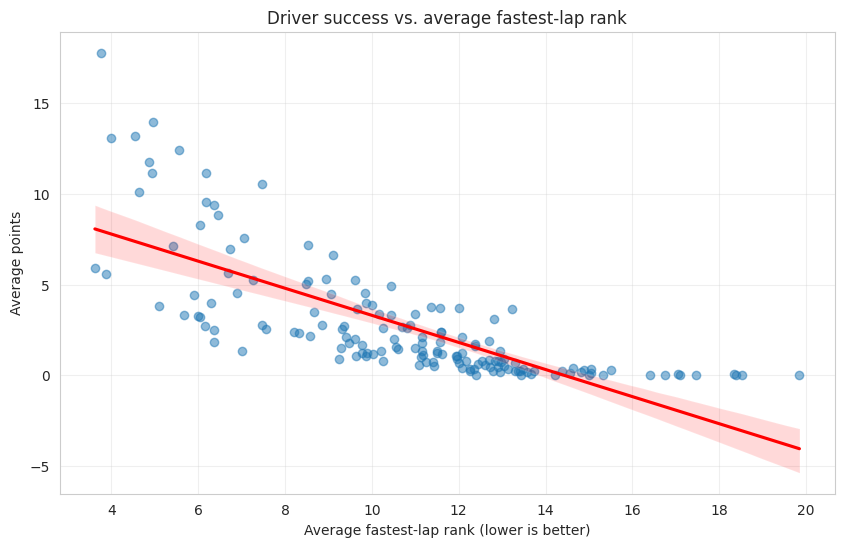

Pit stop R^2: 0.052 (n=143)


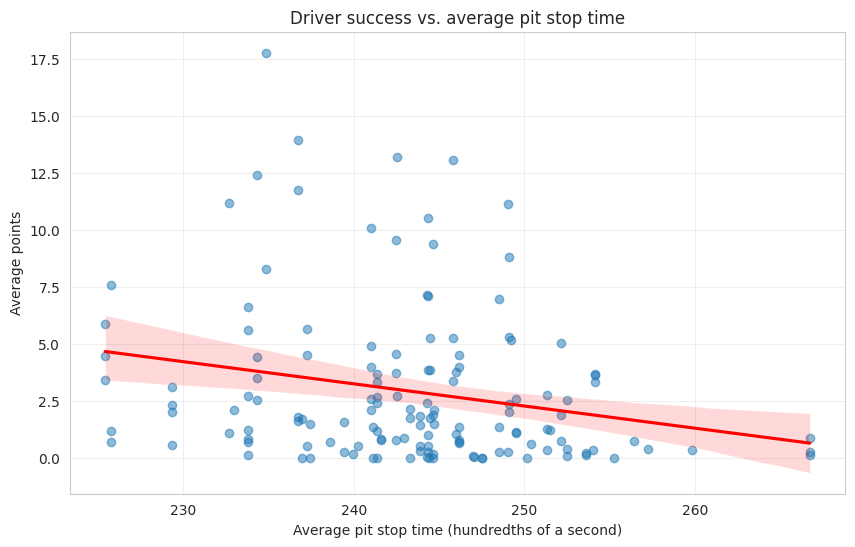

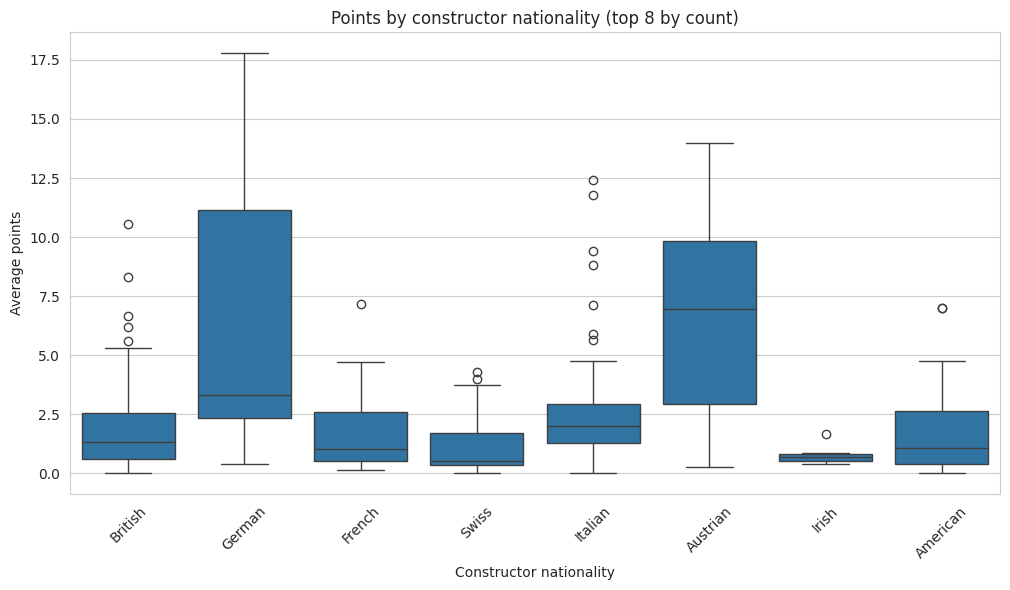

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

analysis_df = final_result[
    [
        "specific_driver_constructor",
        "mean_points",
        "mean_rank",
        "mean_pit_stop_time_second",
        "mean_race_duration_minutes",
        "constructor_nationality",
    ]
].dropna(subset=["mean_points"])

# Summary of the success metric and quick correlations
print("Average points per driver-constructor:")
display(analysis_df[["mean_points"]].describe().T)

corr_cols = [
    "mean_points",
    "mean_rank",
    "mean_pit_stop_time_second",
    "mean_race_duration_minutes",
]
corr_to_success = analysis_df[corr_cols].dropna().corr()["mean_points"].sort_values(ascending=False)
print("Correlation with mean_points (success):")
display(corr_to_success)

# 1) Fastest-lap rank vs. success
rank_df = analysis_df.dropna(subset=["mean_rank"])
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mean_rank",
    y="mean_points",
    data=rank_df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
plt.title("Driver success vs. average fastest-lap rank")
plt.xlabel("Average fastest-lap rank (lower is better)")
plt.ylabel("Average points")
plt.grid(True, alpha=0.3)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    rank_df["mean_rank"], rank_df["mean_points"]
)
print(f"Fastest-lap rank R^2: {r_value**2:.3f} (n={len(rank_df)})")
plt.show()

# 2) Pit stop speed vs. success
pit_df = analysis_df.dropna(subset=["mean_pit_stop_time_second"])
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mean_pit_stop_time_second",
    y="mean_points",
    data=pit_df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
plt.title("Driver success vs. average pit stop time")
plt.xlabel("Average pit stop time (hundredths of a second)")
plt.ylabel("Average points")
plt.grid(True, alpha=0.3)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    pit_df["mean_pit_stop_time_second"], pit_df["mean_points"]
)
print(f"Pit stop R^2: {r_value**2:.3f} (n={len(pit_df)})")
plt.show()

# 3) Constructor context: restrict to top constructors by sample size for a readable plot
top_cons = analysis_df["constructor_nationality"].value_counts().nlargest(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="constructor_nationality",
    y="mean_points",
    data=analysis_df[analysis_df["constructor_nationality"].isin(top_cons)],
)
plt.title("Points by constructor nationality (top 8 by count)")
plt.xlabel("Constructor nationality")
plt.ylabel("Average points")
plt.xticks(rotation=45)
plt.show()

1.Advanced Analysis: Modeling Driver Success

To further validate our findings, we moved beyond simple correlations to multivariate machine learning models. We used Linear Regression to quantify the impact of each variable while holding others constant, and a KNN Classifier to see if we could predict whether a driver belongs to the top 25% performers based solely on their race statistics.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

feature_cols = ["mean_rank", "mean_pit_stop_time_second", "mean_race_duration_minutes"]
model_df = final_result.dropna(subset=feature_cols + ["mean_points"]).copy()

X = model_df[feature_cols]
y = model_df["mean_points"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression baseline
lin_reg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_test)
print(f"Linear regression R^2: {r2_score(y_test, lin_preds):.3f}")
coeffs = pd.Series(lin_reg.named_steps["model"].coef_, index=feature_cols)
print("Linear regression coefficients (scaled features):")
display(coeffs.sort_values())

# Decision tree to allow non-linear splits
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)
print(f"Decision tree R^2: {r2_score(y_test, tree_preds):.3f}")

# KNN classifier: label top-quartile performers as 1, others 0
classification_df = model_df.copy()
threshold = classification_df["mean_points"].quantile(0.75)
classification_df["success_flag"] = (classification_df["mean_points"] >= threshold).astype(int)
Xc = classification_df[feature_cols]
yc = classification_df["success_flag"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc,
    yc,
    test_size=0.2,
    random_state=42,
    stratify=yc,
)
knn = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7)),
    ]
)
knn.fit(Xc_train, yc_train)
yc_pred = knn.predict(Xc_test)
print(f"KNN accuracy (top quartile vs. rest): {accuracy_score(yc_test, yc_pred):.3f}")
print(
    classification_report(
        yc_test, yc_pred, target_names=["not top quartile", "top quartile"]
    )
)

Linear regression R^2: 0.523
Linear regression coefficients (scaled features):


,0
mean_rank,-2.872666
mean_pit_stop_time_second,0.042930
mean_race_duration_minutes,0.527125


Decision tree R^2: 0.712
KNN accuracy (top quartile vs. rest): 0.963
                  precision    recall  f1-score   support

not top quartile       0.95      1.00      0.98        20
    top quartile       1.00      0.86      0.92         7

        accuracy                           0.96        27
       macro avg       0.98      0.93      0.95        27
    weighted avg       0.96      0.96      0.96        27



2. Model Optimization (Cross-Validation & Grid Search)

 To ensure our results are robust and not just due to a lucky data split, we implemented 5-fold Cross-Validation. We also performed Grid Search to find the optimal hyperparameters for our non-linear models.

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

feature_cols = ["mean_rank", "mean_pit_stop_time_second", "mean_race_duration_minutes"]
model_df = final_result.dropna(subset=feature_cols + ["mean_points"]).copy()

X = model_df[feature_cols]
y = model_df["mean_points"]

# 5-fold CV for linear regression (baseline)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
lin_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_cv_scores = cross_val_score(lin_cv_model, X, y, cv=kfold, scoring="r2")
print(f"Linear regression 5-fold R^2: {lin_cv_scores.mean():.3f} +/- {lin_cv_scores.std():.3f}")

# Grid search for decision tree depth/leaf size with 5-fold CV
tree_params = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_leaf": [1, 2, 5, 10],
}
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=kfold,
    scoring="r2",
)
tree_search.fit(X, y)
print(f"Decision tree best 5-fold R^2: {tree_search.best_score_:.3f}")
print("Best params:", tree_search.best_params_)

# KNN classifier tuned via 5-fold CV (top-quartile vs. rest)
classification_df = model_df.copy()
threshold = classification_df["mean_points"].quantile(0.75)
classification_df["success_flag"] = (classification_df["mean_points"] >= threshold).astype(int)
Xc = classification_df[feature_cols]
yc = classification_df["success_flag"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),
])
knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
}
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=skf, scoring="accuracy")
knn_search.fit(Xc, yc)
print(f"KNN best 5-fold accuracy: {knn_search.best_score_:.3f}")
print("Best params:", knn_search.best_params_)


Linear regression 5-fold R^2: 0.601 +/- 0.054
Decision tree best 5-fold R^2: 0.738
Best params: {'max_depth': 5, 'min_samples_leaf': 1}
KNN best 5-fold accuracy: 0.887
Best params: {'model__n_neighbors': 9, 'model__weights': 'uniform'}
